## **Results not used in final project**

In [6]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import re
import seaborn as sns
from nltk.tokenize import word_tokenize, wordpunct_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [7]:
# Load demographic abc data 
demographic_abcs = pd.read_csv('../data/demographic_abcs.csv')

Topics found via LDA:
Topic 1: assistance daily participate
Topic 2: symptoms health mental
Topic 3: assistance threats aggression
Topic 4: destruction property physical


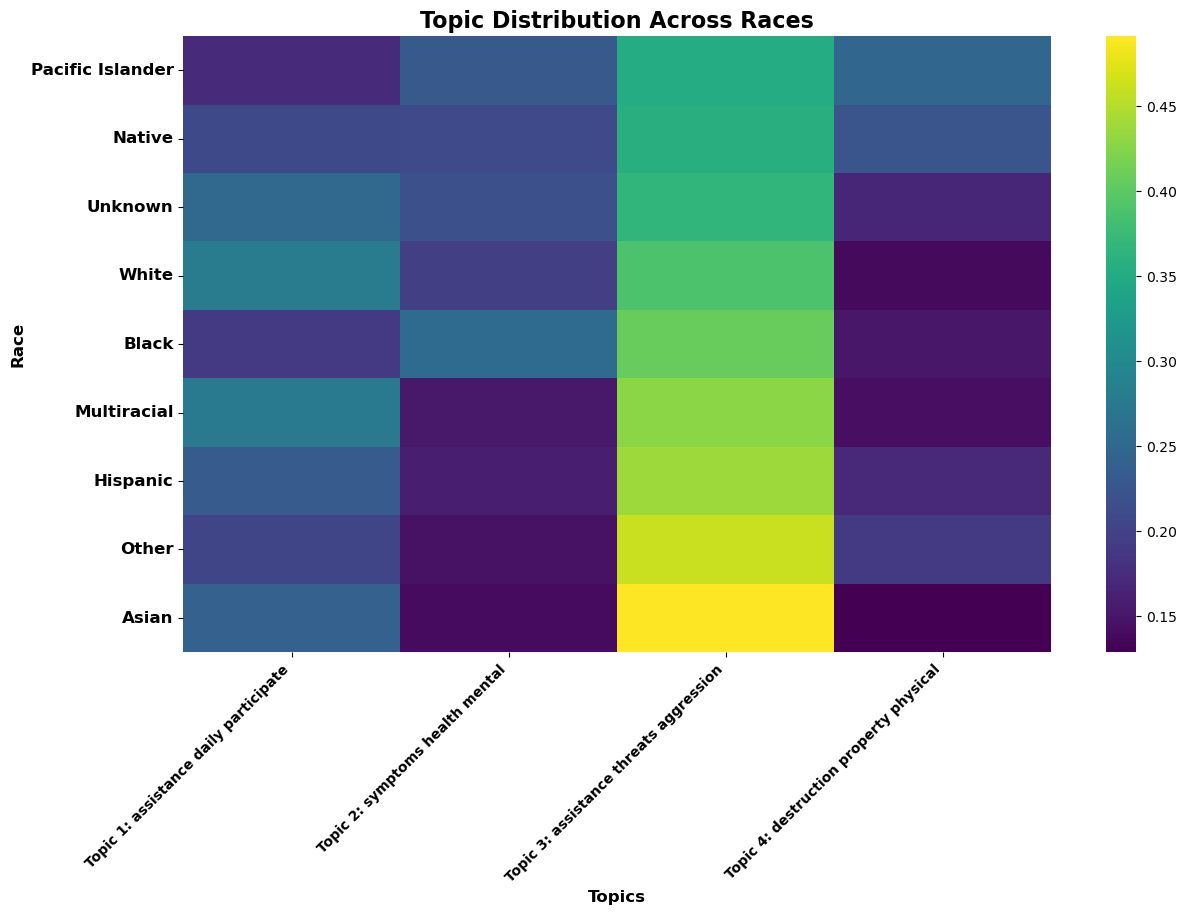

In [9]:
demographic_abcs = demographic_abcs.dropna(subset=['Presenting problems at time of enrollment'])
def preprocess_text(text):
    text = re.sub(r'\s+', ' ', text)  
    text = re.sub(r'[^\w\s]', '', text)  
    text = text.lower()  
    return text
demographic_abcs['cleaned_text'] = demographic_abcs['Presenting problems at time of enrollment'].dropna().apply(preprocess_text)

demographic_abcs['tokenized_text'] = demographic_abcs['cleaned_text'].apply(word_tokenize)
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
text_data = vectorizer.fit_transform(demographic_abcs['cleaned_text'])

# Apply LDA for topic modeling
lda = LatentDirichletAllocation(n_components=4, random_state=42)
lda.fit(text_data)

def display_topics(model, feature_names, no_top_words):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        topic_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        topics.append(" ".join(topic_words))
    return topics

no_top_words = 3
feature_names = vectorizer.get_feature_names_out()
topics = display_topics(lda, feature_names, no_top_words)
print("Topics found via LDA:")
for idx, topic in enumerate(topics):
    print(f"Topic {idx+1}: {topic}")
topic_labels = [f'Topic {i+1}: {" ".join(feature_names[topic.argsort()[:-no_top_words - 1:-1]])}' for i, topic in enumerate(lda.components_)]

# Group by Race and calculate topic distribution
topic_distribution = demographic_abcs.groupby('Race')['cleaned_text'].apply(lambda texts: ' '.join(texts))
topic_distribution = topic_distribution.apply(preprocess_text)

# Vectorize grouped text data
grouped_text_data = vectorizer.transform(topic_distribution)
grouped_topics = lda.transform(grouped_text_data)
topic_df = pd.DataFrame(grouped_topics, index=topic_distribution.index, columns=topic_labels)

# Sort by severity of Topic 3
topic_df_sorted = topic_df.sort_values(by='Topic 3: ' + " ".join(feature_names[lda.components_[2].argsort()[:-no_top_words - 1:-1]]))

# Plot the topic distribution across races
plt.figure(figsize=(14, 8))
sns.heatmap(topic_df_sorted, annot=False, cmap='viridis')
plt.title('Topic Distribution Across Races', fontsize=16, fontweight='bold')
plt.xlabel('Topics', fontsize=12, fontweight='bold')
plt.ylabel('Race', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold') 
plt.yticks(fontsize=12, fontweight='bold')
plt.show()
